# Tutorial python: construcción de redes semánticas con embeddings

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
from sentence_transformers import SentenceTransformer

In [3]:
# Cargmos el modelo de embeddings desde Hugging-Face: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
%time model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CPU times: user 347 ms, sys: 197 ms, total: 544 ms
Wall time: 2.83 s


In [4]:
# Leemos el dataset de texto de noticias
data = pd.read_csv('data/news_data.csv')
data

,text
0,(marketscreener.com) Strong growth in monthly ...
1,The attraction closures take place just before...
2,UNILEVER Philippines is planning to expand its...
3,Wealthspire Advisors LLC bought a new stake in...
4,The ASX is primed to open up 0.6 per cent and ...
...,...
604,(marketscreener.com) L3Harris is pleased to an...
605,"Regulatory News: AFYREN (Paris:ALAFY), a green..."
606,BETA Technologies prototype ALIA CTOL battery-...
607,With airlines expecting this to be the busiest...


In [5]:
# Generamos embeddings para cada texto, donde el embedding es un vector de tamaño 384
## OBS: Si tenemos 609 textos, esto resultará en una matrix de 609 filas y 384 columnas
%time embeddings = model.encode( data['text'] )
embeddings.shape

CPU times: user 726 ms, sys: 235 ms, total: 962 ms
Wall time: 2.56 s


(609, 384)

In [6]:
# Calculamos la similaridad entre cada par de textos
%time similarities = model.similarity(embeddings, embeddings)
similarities.fill_diagonal_(0) # Llenamos la diagonal de 0s, no nos interesa la auto-similaridad
similarities.shape

CPU times: user 4.72 ms, sys: 4.15 ms, total: 8.87 ms
Wall time: 6.51 ms


torch.Size([609, 609])

In [7]:
# Creamos una función para calcular las aristas de los k-vecinos más cercanos
def create_knn_edges(similarities, k=5):
    """Genera las aristas de los k-vecinos más cercanos de la matriz de similaridad."""
    # Empieza con una lista vacía
    edges = []
    
    # para el embedding de cada texto i , registra los k embeddings con mayor similaridad a i
    for i, sims_i in enumerate(similarities):
        
        # ordena los indices de similaridad del texto i del menos al más similar
        sorted_ids = np.argsort(similarities[i])
        # quédate con los k más similares
        k_most_similar = sorted_ids[-k:]
    
        # registra las aristas
        for j in k_most_similar:
            edges.append( (i, int(j)) )

    return edges

Número de nodos: 609
Número de aristas: 2247


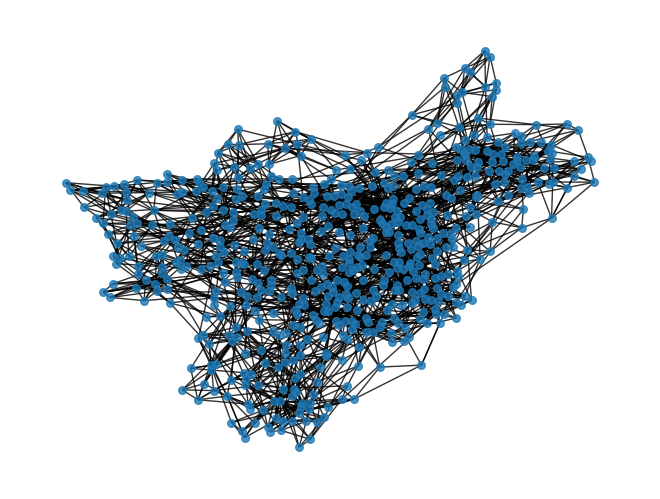

In [8]:
### CONSTRUCCIÓN DE RED SEMANTICA ###
# Genera las aristas de los k-vecinos de los embeddings
edges = create_knn_edges(similarities, k=5)

# Construye la red usando networkX
G = nx.from_edgelist( edges )
print("Número de nodos:", nx.number_of_nodes(G) )
print("Número de aristas:", nx.number_of_edges(G) )

# Visualiza la red
pos = nx.spring_layout(G, seed=42) # calculamos posiciones de los nodos
nx.draw(G, pos, node_size=30, alpha=0.8)

Numero de comunidades: 10


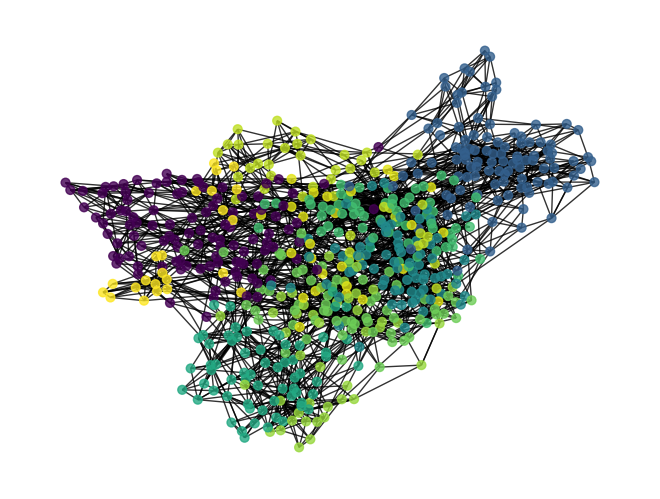

In [9]:
# Ahora, vamos a ver si existen comunidades de noticias usando el método de maximización de modularidad
C = nx.community.louvain_communities(G)

# Limpiamos las comunidades: 1) ordenamos de más a menos grandes, 2) creamos un diccionario nodo:comunidad
C = sorted(C, key=len, reverse=True)
C_dict = {node: i for i, comm in enumerate(C) for node in comm}
# Le asignamos a cada nodo un color distinto
colors = [ np.log(C_dict[n] + 1) for n in G.nodes()]
print(f"Numero de comunidades: {len(C)}")

# Visualizamos comunidades
nx.draw(G, pos, node_size=40, alpha=0.8, node_color=colors)

In [10]:
# Generamos una función para ver el texto dentro de una comunidad dada
def print_texts_in_community(data, community, max_texts=5):
    texts_in_community = data.loc[list(community),'text']
    
    n_texts = min(max_texts, len(texts_in_community))
    for i in range(n_texts):
        text = texts_in_community.iloc[i]
        print( f"TEXT: {text}", end="\n\n" )

In [11]:
# Veamos algunos de los textos dentro de comunidades
community = C[0]
print_texts_in_community(data, community, max_texts=10)

TEXT: Once an aspiring Olympian, Landon Driggers wants everyone to know he's more than his sport.

TEXT: It seems that EA is looking to make EA Sports FC 24 even more expensive, with a new paid season pass as well as loot boxes.

TEXT: The attraction closures take place just before the Halloween crowds descend on the Disney parks.

TEXT: Terrell Owens thinks Tom Brady disrespected him about three years ago, and the Hall of Fame wide receiver is still not over it. In a recent appearance on the &#8220;Bubba Dub Show,&#8221; Owens claimed he had reached out to Brady in 2021, after Antonio Brown famously walked out on the Tampa Bay Buccaneers on the...The post Terrell Owens claims to have been disrespected by Tom Brady appeared first on Larry Brown Sports.

TEXT: Jake Paul first tiptoed into a boxing ring in 2018 in a celebrity boxing fight. He has come a long way since then and proved that he is here to stay. The 27-year-old has brought new eyes to the sport, leading to increased revenue.

In [12]:
# Calculamos la centralidad de grado usando networkx
centralities = nx.centrality.degree_centrality(G)
centralities = pd.Series(centralities)

# Extraemos los nodos de mayor y menor centralidad
most_central = centralities.nlargest(5).index
least_central = centralities.nsmallest(5).index

print("###### TEXTOS CON MAYOR CENTRALIDAD DGRADO ######\n")
print_texts_in_community(data, most_central)

print("###### TEXTOS CON MENOR CENTRALIDAD DGRADO ######\n")
print_texts_in_community(data, least_central)


###### TEXTOS CON MAYOR CENTRALIDAD DGRADO ######

TEXT: (marketscreener.com) NEW YORK, July 11, 2024 /PRNewswire/ --&nbsp;Monteverde &amp; Associates PC , has recovered money for shareholders and is recognized as a Top 50&nbsp;Firm in the 2018-2022 ISS Securities Class Action Services Report. We are headquartered at the&nbsp;Empire State Building&nbsp;in New York City and are investigating Strong Global Entertainment,...https://www.marketscreener.com/quote/stock/STRONG-GLOBAL-ENTERTAINME-154226644/news/The-M-A-Class-Action-Firm-Investigates-Merger-of-Strong-Global-Entertainment-Inc-SGE-47366714/?utm_medium=RSS&utm_content=20240711

TEXT: (marketscreener.com) July 16, 2024 Company Name: Universal Entertainment Corporation ...https://www.marketscreener.com/quote/stock/UNIVERSAL-ENTERTAINMENT-C-6814877/news/Universal-Entertainment-Notice-Concerning-Establishment-of-Record-Date-for-Convocation-of-Extraord-47388819/?utm_medium=RSS&utm_content=20240716

TEXT: (marketscreener.com) FOCUS ENTE

In [15]:
# También podemos hacer queries y ver a qué embedding se parece más.
query_emb = model.encode("Query: music and korea")
most_similar = np.argmax(model.similarity(query_emb, embeddings))
data.loc[int(most_similar),'text']

'K-pop girl group Unis is making a comeback in August. According to F&F Entertainment, Unis is introducing its new single &ldquo;Curious&rdquo; on Aug. 6. Unis is a K-pop girl group comprising eight finalists from the SBS audition program &ldquo;Universe Ticket&rdquo; that debuted with its first mini album &ldquo;We Unis&rdquo; in March. The album sold more than 55,000 copies just within five days of its release. Unis recently won the Asia Star Award at the 2024 Korea Best Brand Awards held i'